In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sys
from scipy.spatial.distance import cdist

sys.path.append(r"D:/Football Project/src")

import feature_lists as fl

### I have concluded from the previous smaller database that average produces better clusters ###

In [35]:
df_avg=pd.read_csv('../../../data/processed/major_leagues/Defenders/Avg_Major_Defenders.csv')

In [36]:
X_avg=df_avg.drop(columns=fl.metadata_features + ['minutesplayed','number_of_seasons','appearances','matchesstarted'])

In [37]:
X_avg.shape

(1723, 67)

In [38]:
scaler = StandardScaler()
X_avg_scaled = scaler.fit_transform(X_avg)

In [39]:
inertia_avg = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    km.fit(X_avg_scaled)
    inertia_avg.append(km.inertia_)

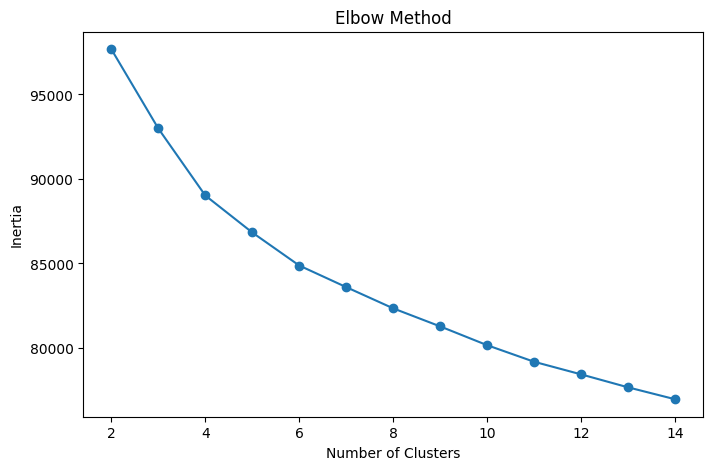

In [40]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    inertia_avg,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [41]:
scores_avg = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = km.fit_predict(X_avg_scaled)
    
    score = silhouette_score(X_avg_scaled, labels)
    scores_avg.append(score)

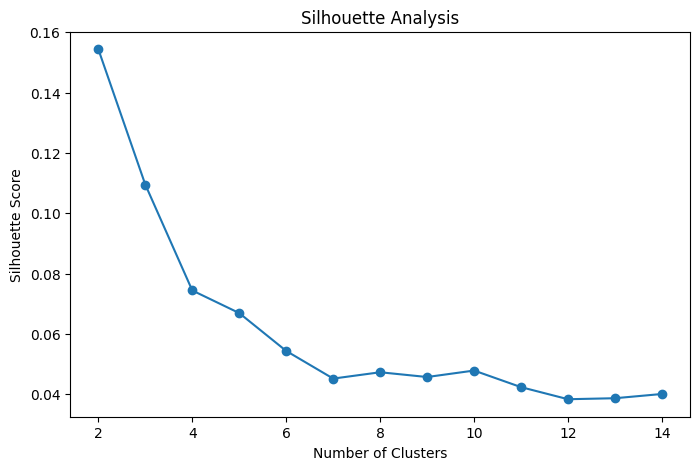

In [42]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    scores_avg,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

In [43]:
x=5
kmeans = KMeans(
    n_clusters=x,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_avg_scaled)

df_avg[f"cluster_{x}"] = labels

In [44]:
cluster_avg_summary = (df_avg.drop(columns=fl.metadata_features).groupby(f"cluster_{x}").mean())

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(cluster_avg_summary.transpose())

cluster_5,0,1,2,3,4
number_of_seasons,2.118483,2.259259,2.392982,2.168803,2.190164
appearances,24.137836,27.068587,26.786550,25.735399,25.301639
matchesstarted,21.398104,21.541152,24.429240,21.136040,22.687432
minutesplayed,1912.198262,1935.943759,2185.754386,1881.453704,2028.815847
dispossessed_per_touch_zscore,-0.500501,1.044095,-0.509313,0.671980,-0.506475
groundduelswon_per90_zscore,-0.625266,0.945025,-0.239966,0.688815,-0.493316
keypasses_per90_zscore,-0.693636,1.438619,-0.382488,0.488777,-0.586512
expectedgoals_per90_zscore,-0.298544,0.470165,0.175070,-0.338757,0.476723
yellowcards_per90_zscore,-0.055541,-0.000435,0.028476,-0.005884,0.056560
accuratecrossespercentage_zscore,-0.161101,0.195615,0.063008,0.152474,-0.163555


In [45]:
pca = PCA(n_components=2)

X_avg_pca = pca.fit_transform(X_avg_scaled)

df_avg["PC1"] = X_avg_pca[:,0]
df_avg["PC2"] = X_avg_pca[:,1]

fig = px.scatter(
    df_avg,
    x="PC1",
    y="PC2",
    color=f"cluster_{x}",
    hover_name='player',         
    hover_data=['team','appearances','minutesplayed'], 
    title=f"Midfielders Avg Clusters (K={x})",
    width=1000,
    height=700
)

fig.show()

In [46]:
df_avg[f"cluster_{x}"].value_counts()

cluster_5
3    468
0    422
4    305
2    285
1    243
Name: count, dtype: int64

### 5 clusters are better than 4 as Ball playing Defenders are seperated when clusters = 5 ###

In [47]:
pca = PCA()

X_pca = pca.fit_transform(X_avg_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)

In [48]:
var_df = pd.DataFrame({
    "Components": range(1, len(cum_var)+1),
    "Cumulative Variance": cum_var
})

px.line(
    var_df,
    x="Components",
    y="Cumulative Variance",
    title="PCA Explained Variance"
).show()

In [49]:
pca_sizes = range(19,27)

pca_datasets = {}

for n in pca_sizes:
    pca = PCA(n_components=n, random_state=42)
    pca_datasets[n] = pca.fit_transform(X_avg_scaled)

In [50]:
results = []

for n_comp, X_pca in pca_datasets.items():

    for k in range(4, 11):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        labels = kmeans.fit_predict(X_pca)

        sil = silhouette_score(X_pca, labels)

        results.append(
            {
                "n_components": n_comp,
                "k": k,
                "silhouette": sil
            }
        )

In [51]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "silhouette",
    ascending=False
).head(20)

,n_components,k,silhouette
0,19,4,0.104966
7,20,4,0.103558
14,21,4,0.101417
21,22,4,0.099426
1,19,5,0.097931
28,23,4,0.097570
8,20,5,0.096406
35,24,4,0.095414
15,21,5,0.094282
42,25,4,0.094099


In [52]:
x=19
pca = PCA(n_components=x)
X_pca = pca.fit_transform(X_avg_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_avg.columns.tolist(),
    columns=[f"PC{i+1}" for i in range(x)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19
dispossessed_per_touch_zscore,0.205532,-0.048293,-0.130004,-0.022837,0.032607,-0.046949,-0.002401,-0.155654,-0.064413,0.041962,-0.114438,-0.143147,0.061210,0.130915,0.041308,0.010268,0.083177,-0.086286,-0.139405
groundduelswon_per90_zscore,0.203070,-0.019079,-0.136031,0.195866,0.181787,0.069546,0.065660,-0.146789,-0.073168,-0.028918,-0.012685,0.012125,0.000178,0.012442,-0.063494,-0.007931,-0.065699,0.009356,0.069174
keypasses_per90_zscore,0.236386,0.021846,0.093316,-0.031008,-0.060192,0.052033,0.003899,0.059548,0.091838,-0.029328,-0.057124,0.003515,0.003806,-0.173828,-0.041685,0.005141,0.022670,0.069410,0.001852
expectedgoals_per90_zscore,0.017463,0.277017,-0.080305,0.012670,-0.186127,-0.068637,0.045067,-0.149507,-0.004559,0.047195,0.085863,0.012209,-0.046138,-0.037823,0.063043,-0.022267,-0.082838,-0.017203,0.063919
yellowcards_per90_zscore,0.008962,0.006072,-0.154160,0.120914,0.061328,-0.103209,-0.205830,0.118783,-0.207027,-0.241560,-0.018333,0.235040,-0.213487,-0.147277,-0.142805,0.076959,-0.037556,0.155686,0.069698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
dribbledpast_per90_zscore,0.170103,-0.029430,-0.100168,0.088031,0.105676,-0.126003,-0.083892,0.101228,0.035901,0.156363,0.103287,0.089568,-0.066896,-0.017092,-0.033229,-0.086988,-0.139556,-0.031206,0.020946
offsides_per90_zscore,0.111529,0.035607,-0.051318,-0.047316,-0.088805,0.001962,-0.012049,-0.114922,0.083929,-0.117570,-0.125119,-0.082577,-0.028927,-0.180529,-0.025294,-0.012096,0.099343,0.163085,0.065943
xa_per_keypass_zscore,-0.002562,0.029710,0.061501,0.028303,-0.029643,-0.040450,-0.039519,-0.083698,0.141612,-0.186322,-0.038937,0.424873,0.441543,0.374959,0.253737,0.094803,0.044920,-0.098218,0.053001
accurateoppositionhalfpasses_per90_zscore,0.093997,0.073168,0.331223,0.188324,-0.001192,-0.106011,-0.118091,-0.085649,0.065616,-0.131922,0.139033,-0.062231,0.001185,-0.029434,-0.013719,-0.065504,-0.026326,-0.031407,-0.038776


In [53]:
for pc in loadings.columns:
    print(f"\n{pc}")
    print(loadings[pc].abs().sort_values(ascending=False).head(10))


PC1
final_third_pass_pct_zscore           0.248731
keypasses_per90_zscore                0.236386
clearances_per90_zscore               0.225712
possessionwonattthird_per90_zscore    0.219182
possession_lost_per_touch_zscore      0.209198
expectedassists_per90_zscore          0.207204
dispossessed_per_touch_zscore         0.205532
bigchancescreated_per90_zscore        0.204542
successfuldribbles_per90_zscore       0.203569
groundduelswon_per90_zscore           0.203070
Name: PC1, dtype: float64

PC2
goals_per90_zscore                    0.333196
shotsontarget_per90_zscore            0.302261
shotsfrominsidethebox_per90_zscore    0.299764
expectedgoals_per90_zscore            0.277017
headedgoals_per90_zscore              0.238683
goalsassistssum_per90_zscore          0.237019
goalconversionpercentage_zscore       0.227212
shotsofftarget_per90_zscore           0.218656
bigchancesmissed_per90_zscore         0.195161
rightfootgoals_per90_zscore           0.176974
Name: PC2, dtype: float6

In [54]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(x)]
)

In [55]:
results=[]
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_pca)

    results.append({
        "k": k,
        "silhouette": silhouette_score(X_pca, labels),
        "inertia": kmeans.inertia_
    })

df_results = pd.DataFrame(results)

In [56]:
px.line(
    df_results,
    x="k",
    y="inertia",
    markers=True,
    title="Elbow Method"
).show()

px.line(
    df_results,
    x="k",
    y="silhouette",
    markers=True,
    title="Silhouette Score"
).show()

In [57]:
cluster=5

kmeans_pca = KMeans(n_clusters=cluster, random_state=42, n_init=20)
df_avg[f'pca_cluster_{cluster}'] = kmeans_pca.fit_predict(X_pca)

cluster_summary = (df_avg.drop(columns=fl.metadata_features+['cluster_5','PC1','PC2',]).groupby(f"pca_cluster_{cluster}").mean())

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(cluster_summary.transpose())

pca_cluster_5,0,1,2,3,4
number_of_seasons,2.125874,2.265306,2.168966,2.169133,2.398601
appearances,24.150350,27.163265,25.221264,25.644116,26.922494
matchesstarted,21.432401,21.667347,22.587931,21.048978,24.575175
minutesplayed,1915.654623,1946.983673,2020.190230,1873.575405,2198.419580
dispossessed_per_touch_zscore,-0.509954,1.038449,-0.513229,0.663501,-0.501010
groundduelswon_per90_zscore,-0.634763,0.940215,-0.517196,0.676622,-0.205602
keypasses_per90_zscore,-0.698920,1.433562,-0.582279,0.478088,-0.387895
expectedgoals_per90_zscore,-0.288166,0.470003,0.494528,-0.342967,0.182885
yellowcards_per90_zscore,-0.053960,0.000778,0.052771,-0.004658,0.031212
accuratecrossespercentage_zscore,-0.163492,0.194896,-0.161973,0.150475,0.060024


In [58]:
df_avg["PC1"] = X_pca[:,0]
df_avg["PC2"] = X_pca[:,1]

fig = px.scatter(
    df_avg,
    x="PC1",
    y="PC2",
    color=f"pca_cluster_{cluster}",
    hover_name='player',         
    hover_data=['team','minutesplayed','number_of_seasons'], 
    title=f"Defenders Clusters (K={cluster})",
    width=1000,
    height=700
)

fig.show()

### The Ball Playing Defender Cluster been moved beautifully we can even see a lot of CB who were classified as Full Backs earlier are now correctly clustered an example would be Bastoni located near PC1 = 2.5 and PC2 = 2.7 ###

In [59]:
y=cluster
distances = cdist(X_pca, kmeans_pca.cluster_centers_)

for cluster in range(cluster):

    members = df_avg[df_avg[f"pca_cluster_5"] == cluster]

    member_idx = members.index

    d = distances[member_idx, cluster]

    closest_idx = member_idx[np.argsort(d)[:20]]
    
    print('cluster number-' ,cluster)

    print(df_avg.loc[closest_idx, ["player","team"]])

cluster number- 0
                    player             team
1182                 Natan       Real Betis
171        Norbert Gyömbér       Al-Kholood
224         Martin Valjent         Mallorca
1513          David Torres  Real Valladolid
207         Timo Baumgartl    FC Schalke 04
680        Montassar Talbi          Lorient
732             Max Kilman  West Ham United
584             Enea Mihaj        Famalicão
1464          Yael Mouanga      Montpellier
463   Mohammed Al-Khabrani       Al-Khaleej
878           Lucas Perrin   Sporting Gijón
1022         Botond Balogh      Kocaelispor
374            Noah Loosli  VfL Bochum 1848
1349         Maxime Estève          Burnley
1061         Shawn Adewoye  Fortuna Sittard
694         Nicholas Opoku        Kasımpaşa
1092         Loïc Williams          Granada
708           Attila Mocsi  Çaykur Rizespor
979             Toti Gomes    Wolverhampton
1100          Marco Moreno            Eibar
cluster number- 1
                    player              

In [60]:
cluster_mapping = {
    0: "Deep CB",
    1: "Attacking Fullback",
    2: "Aerial CB",
    3: "Defensive Fullback",
    4: "Ball Playing CB"
}

df_avg['cluster']=df_avg['pca_cluster_5']
df_avg=df_avg.drop(columns=['cluster_5','pca_cluster_5'])
df_avg['cluster_name']=df_avg["cluster"].map(cluster_mapping)

In [61]:
df_ewma=pd.read_csv('../../../data/processed/major_leagues/Defenders/EWMA_Major_Defenders.csv')

In [62]:
import joblib

joblib.dump(scaler, "../../../models/major_leagues/Defenders/scaler.pkl")
joblib.dump(pca, "../../../models/major_leagues/Defenders/pca.pkl")
joblib.dump(kmeans_pca, "../../../models/major_leagues/Defenders/kmeans.pkl")

['../../../models/major_leagues/Defenders/kmeans.pkl']

In [63]:
X_pca_avg = pca.transform(X_avg_scaled)
pca_cols = [f'PC{i+1}' for i in range(19)]
df_coords_avg = pd.DataFrame(X_pca_avg, columns=pca_cols, index=df_avg.index)

df_avg_clustered = pd.concat([df_avg, df_coords_avg], axis=1)
df_avg_clustered['cluster'] = kmeans_pca.labels_
df_avg_clustered['cluster_name'] = df_avg_clustered['cluster'].map(cluster_mapping)

df_avg_clustered.to_csv('../../../data/processed/major_leagues/Defenders/Avg_Major_Defenders_Clustered.csv', index=False)

In [64]:
X_ewma=df_ewma.drop(columns=fl.metadata_features + ['minutesplayed','number_of_seasons','appearances','matchesstarted'])

X_scaled_ewma = scaler.transform(X_ewma)
X_pca_ewma = pca.transform(X_scaled_ewma)

pca_cols = [f'PC{i+1}' for i in range(19)]
df_coords_ewma = pd.DataFrame(X_pca_ewma, columns=pca_cols, index=df_ewma.index)

df_ewma_clustered = pd.concat([df_ewma, df_coords_ewma], axis=1)

df_ewma_clustered['cluster']=df_avg['cluster']
df_ewma_clustered['cluster_name']=df_avg['cluster_name']

df_ewma_clustered.to_csv('../../../data/processed/major_leagues/Defenders/EWMA_Major_Defenders_Clustered.csv', index=False)

### I really liked the clustering on Defenders and i have saved this clustering to my data ###